In [1]:
import numpy as np
import os, sys
import xarray as xr
import pandas as pd
import math
from skimage.draw import disk
from scipy.ndimage import convolve, binary_erosion, generate_binary_structure
from scipy.fft import fft2, ifft2
# from astropy.convolution import Box2DKernel, convolve
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import copy
import colorcet as cc

In [2]:
dir_cellmask = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190123/gefs18/base/d3/celltracking/20190123.1200_20190124.0000/'
dir_lasso = f'/gpfs/wolf2/arm/cli120/world-shared/d3m088/cacti/staged_runs_2/20190123/gefs18/base/les/subset_d3/'

in_date = '20190123'
in_time = '190000'
basename_lasso = f'corlasso_methagl_2019012300gefs18d3_base_M1.m1.'
basename_cellmask = f'celltracks_'

file_cellmask = f'{dir_cellmask}{basename_cellmask}{in_date}_{in_time}.nc'
file_lasso = f'{dir_lasso}{basename_lasso}{in_date}.{in_time}.nc'

In [3]:
print(f"cellmask file exist: {os.path.isfile(file_cellmask)}")
print(f"LASSO file exist: {os.path.isfile(file_lasso)}")

cellmask file exist: True
LASSO file exist: True


In [4]:
dsm = xr.open_dataset(file_cellmask)
lat_m = dsm.latitude.squeeze()
lon_m = dsm.longitude.squeeze()
dsm

<xarray.Dataset>
Dimensions:                 (time: 1, lat: 554, lon: 475)
Coordinates:
  * time                    (time) datetime64[ns] 2019-01-23T19:00:00
  * lon                     (lon) float32 -65.94 -65.93 -65.93 ... -63.36 -63.36
  * lat                     (lat) float32 -33.3 -33.3 -33.29 ... -30.8 -30.79
Data variables: (12/30)
    radar_longitude         int64 ...
    radar_latitude          int64 ...
    base_time               (time) datetime64[ns] ...
    longitude               (lat, lon) float32 ...
    latitude                (lat, lon) float32 ...
    x                       (lon) int64 ...
    ...                      ...
    merge_tracknumber       (time, lat, lon) float64 ...
    split_tracknumber       (time, lat, lon) float64 ...
    track_status            (time, lat, lon) float64 ...
    cloudtracknumber        (time, lat, lon) float64 ...
    cloudmerge_tracknumber  (time, lat, lon) float64 ...
    cloudsplit_tracknumber  (time, lat, lon) float64 ...
Attributes: (12/22)
    Title:                Pixel-level feature tracking data
    Contact:              Zhe Feng, zhe.feng@pnnl.gov
    Institution:          Pacific Northwest National Laboratory
    Created_on:           Thu Jan  4 19:44:51 2024
    Input_File:           /gpfs/wolf/atm131/proj-shared/money/20190123/gefs18...
    dx:                   500
    ...                   ...
    weakEchoThres:        15
    bkgrndRadius:         11
    min_corearea:         4
    echotop_gap:          4
    sfc_dz_min:           500
    sfc_dz_max:           3000

In [5]:
ds = xr.open_dataset(file_lasso)
XLONG = ds.XLONG.squeeze()
XLAT = ds.XLAT.squeeze()
dx = ds.attrs['DX']
dy = ds.attrs['DY']
ds

<xarray.Dataset>
Dimensions:      (Time: 1, south_north: 865, west_east: 750, HAGL: 33)
Coordinates:
  * Time         (Time) datetime64[ns] 2019-01-23T19:00:00
    XLONG        (south_north, west_east) float32 ...
    XLAT         (south_north, west_east) float32 ...
    XTIME        (Time) float32 ...
  * HAGL         (HAGL) float64 50.0 100.0 200.0 ... 4.5e+03 4.75e+03 5e+03
Dimensions without coordinates: south_north, west_east
Data variables: (12/41)
    ITIMESTEP    (Time) int32 ...
    HGT          (Time, south_north, west_east) float32 ...
    MUTOT        (Time, south_north, west_east) float32 ...
    PRESSURE     (Time, HAGL, south_north, west_east) float32 ...
    ALT          (Time, HAGL, south_north, west_east) float32 ...
    TEMPERATURE  (Time, HAGL, south_north, west_east) float32 ...
    ...           ...
    MULCL        (Time, south_north, west_east) float32 ...
    MULFC        (Time, south_north, west_east) float32 ...
    MULNB        (Time, south_north, west_east) float32 ...
    MULPL        (Time, south_north, west_east) float32 ...
    MUCAPE       (Time, south_north, west_east) float32 ...
    MUCIN        (Time, south_north, west_east) float32 ...
Attributes: (12/39)
    DX:                          500.0
    DY:                          500.0
    SIMULATION_START_DATE:       2019-01-23_06:00:00
    WEST-EAST_GRID_DIMENSION:    751
    SOUTH-NORTH_GRID_DIMENSION:  866
    BOTTOM-TOP_GRID_DIMENSION:   150
    ...                          ...
    doi_isPartOf_lasso-cacti:    https://doi.org/10.5439/1905789
    doi_isDocumentedBy:          https://doi.org/10.2172/1905845
    doi_thisFileType:            https://doi.org/10.5439/1905822
    history:                     processed by user d3m088 on machine cirrus20...
    filename_user:               corlasso_methagl_2019012300gefs18d3_base_M1....
    filename_storage:            corlassomethagl2019012300gefs18d3baseM1.m1.2...

In [6]:
def circular_mask(bkg_rad, dx=None, dy=None):
    # Convert background bkg_radius to number of grid points
    bkg_rad_x = int(bkg_rad / dx)
    bkg_rad_y = int(bkg_rad / dy)
    
    # Get a background radius mask
    ygrd, xgrd = np.ogrid[-bkg_rad_y:bkg_rad_y+1, -bkg_rad_x:bkg_rad_x+1]
    mask = xgrd*xgrd + ygrd*ygrd <= (bkg_rad/dx)*(bkg_rad/dy)
    return mask

In [7]:
# def circular_mask2(window_size, radius):
#     """Generate a circular mask."""
#     mask = np.zeros((window_size, window_size), dtype=np.float64)
#     rr, cc = disk((window_size // 2, window_size // 2), radius)
#     mask[rr, cc] = 1
#     return mask / np.sum(mask)

In [8]:
def circular_mask(radius, resolution):
    """
    Generate a circular mask.
    
    Parameters:
    - radius: Radius of the circle.
    - resolution: The resolution of each pixel.
    
    Returns:
    - mask: 2D numpy array representing the circular mask.
    """
    # Calculate the radius in pixels
    radius_px = radius / resolution
    
    # Calculate the window size to fully contain the circle
    window_size = int(np.ceil(radius_px * 2)) + 1
    
    # Create the circular mask
    mask = np.zeros((window_size, window_size), dtype=np.float64)
    rr, cc = disk((window_size // 2, window_size // 2), radius_px)
    mask[rr, cc] = 1
    
    # Normalize the mask
    mask /= np.sum(mask)
    
    return mask

In [9]:
# bkg_rad = 50.0 * 1000  # [m]
# window_size = int(bkg_rad / dx) * 2
# window_size

In [10]:
bkg_rad = 50.0 * 1000 # [m]
mask_convol = circular_mask(bkg_rad, dx)

# bkg_rad = 50.0 * 1000  # [m]
# mask_convol = circular_mask(bkg_rad, dx, dy)

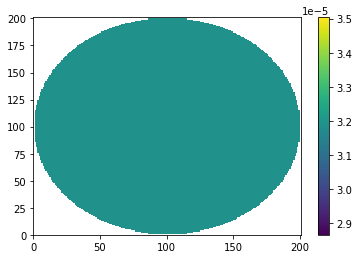

In [11]:
_mask_convol = np.ma.masked_where(mask_convol == 0, mask_convol)
plt.pcolormesh(_mask_convol)
plt.colorbar()

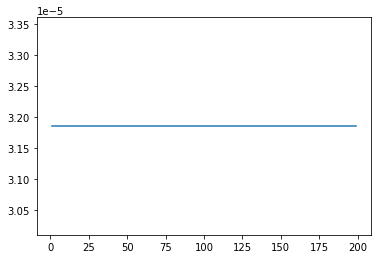

In [12]:
plt.plot(_mask_convol[100,:])

In [13]:
# Calcuate virtual potential temperature. Original formula should have Qcloud, Qrain.
# thetav = theta*(1. + 0.608*qv + qc + qr)  # virtual potential temperature (K)
THETA_V = ds['THETA'] * (1 + 0.608 * ds['QVAPOR'])

buoy_z = 50
THETA_V_ll = THETA_V.sel(HAGL=buoy_z).squeeze()
# THETA_V_ll_bar = 

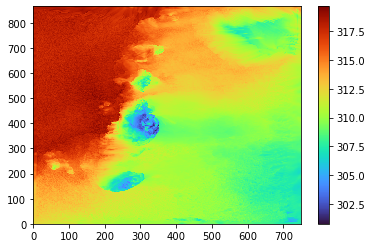

In [14]:
plt.pcolormesh(THETA_V_ll, cmap='turbo')
plt.colorbar()

In [15]:
%%time
# Virtual potential temperature horizontal mean over mesoscale
THETA_V_ll_bar = convolve(THETA_V_ll.values, mask_convol, mode='nearest')

CPU times: user 29.3 s, sys: 683 ms, total: 30 s
Wall time: 30.3 s


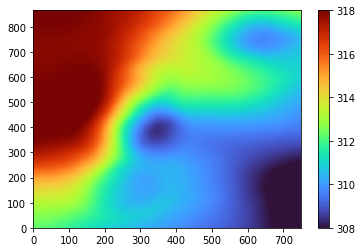

In [16]:
plt.pcolormesh(THETA_V_ll_bar, vmin=308, vmax=318, cmap='turbo')
plt.colorbar()

In [17]:
# Calculate buoyancy in relation to mesoscale mean [m/s^2]
buoy = 9.81*(THETA_V_ll - THETA_V_ll_bar)/THETA_V_ll_bar
# 
buoy_thres = -0.05
# buoy_negative = np.copy(buoy)
# buoy_negative = buoy.copy(deep=True)
buoy_negative = buoy.where(buoy < buoy_thres).copy(deep=True)
# buoy_negative[buoy >= buoy_thres] = np.NaN

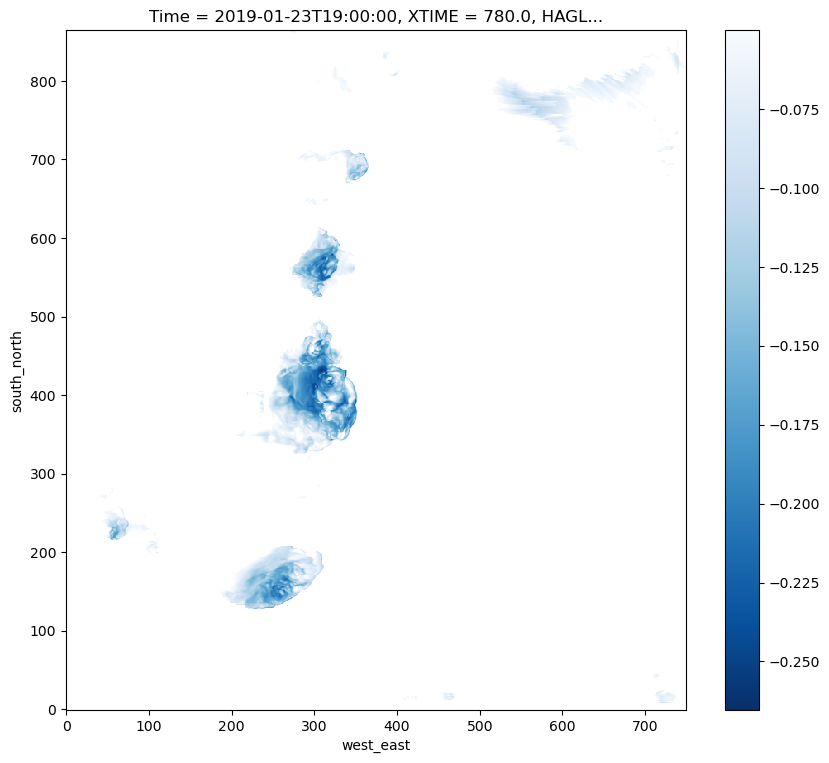

In [18]:
fig = plt.figure(figsize=(10,9), dpi=100)
buoy_negative.plot.pcolormesh(cmap='Blues_r')
# plt.pcolormesh(buoy_negative, cmap='Blues_r')
# plt.colorbar()

In [19]:
# lonmin = lon_m.min().item()
# lonmax = lon_m.max().item()
# latmin = lat_m.min().item()
# latmax = lat_m.max().item()
# [lat_min, lon_min, lat_max, lon_max]
geolimits = [-33.3, -65.9, -30.8, -63.4]
buffer = 0
latmin, latmax = geolimits[0]-buffer, geolimits[2]+buffer
lonmin, lonmax = geolimits[1]-buffer, geolimits[3]+buffer
print(latmin, latmax)
print(lonmin, lonmax)

# Make a 2D mask for subsetting the domain
mask_subset = ((XLONG >= lonmin) & (XLONG <= lonmax) & \
        (XLAT >= latmin) & (XLAT <= latmax)).squeeze()
# Get y/x indices limits from the mask
y_idx, x_idx = np.where(mask_subset == True)
xmin, xmax = np.min(x_idx), np.max(x_idx)
ymin, ymax = np.min(y_idx), np.max(y_idx)

-33.3 -30.8
-65.9 -63.4


In [20]:
# Subset buoyancy
buoy_s = buoy_negative.where(mask_subset, drop=True).squeeze()

In [22]:
# Subset DataSet
dss = ds.where(mask_subset, drop=True).squeeze()
# Rename dimensions
y_dimname = 'south_north'
x_dimname = 'west_east'
dss = dss.rename({x_dimname: 'lon', y_dimname: 'lat'})

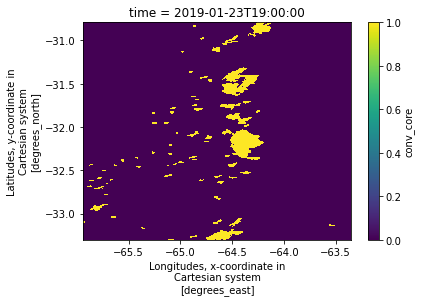

In [23]:
# (dsm.conv_mask > 0).plot()
# dsm.conv_mask.plot()
(dsm.conv_core > 0).plot()

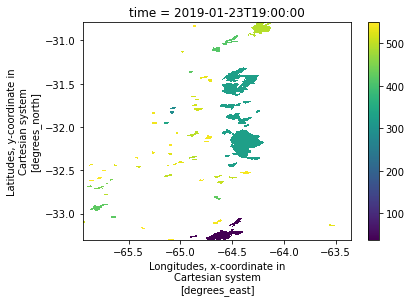

In [24]:
celltracknumber = (dsm.cloudtracknumber * (dsm.conv_core > 0)).squeeze()
celltracknumber = celltracknumber.where(celltracknumber > 0)
celltracknumber.plot()

In [25]:
_celltracknumber = np.ma.masked_where(np.isnan(celltracknumber), celltracknumber)
_celltracknumber.shape, buoy_negative.where(mask_subset, drop=True).shape

((554, 475), (554, 475))

In [26]:
W_z = 500
UV_z = 100
W_ll = dss.WA.sel(HAGL=W_z)
U_ll = dss.UA.sel(HAGL=UV_z)
V_ll = dss.VA.sel(HAGL=UV_z)
HGT = dss.HGT

In [27]:
# buoy_s.plot()
# np.arange(-0.2, -0.05, 0.01)
map_extent = (xmin, xmax, ymin, ymax)
map_extent

(60, 534, 147, 700)

In [33]:
dbz_comp = dsm.dbz_comp.squeeze()
echotop10 = dsm.echotop10.squeeze()/1000.

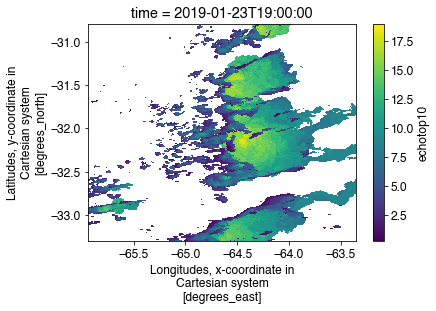

In [34]:
echotop10.plot()

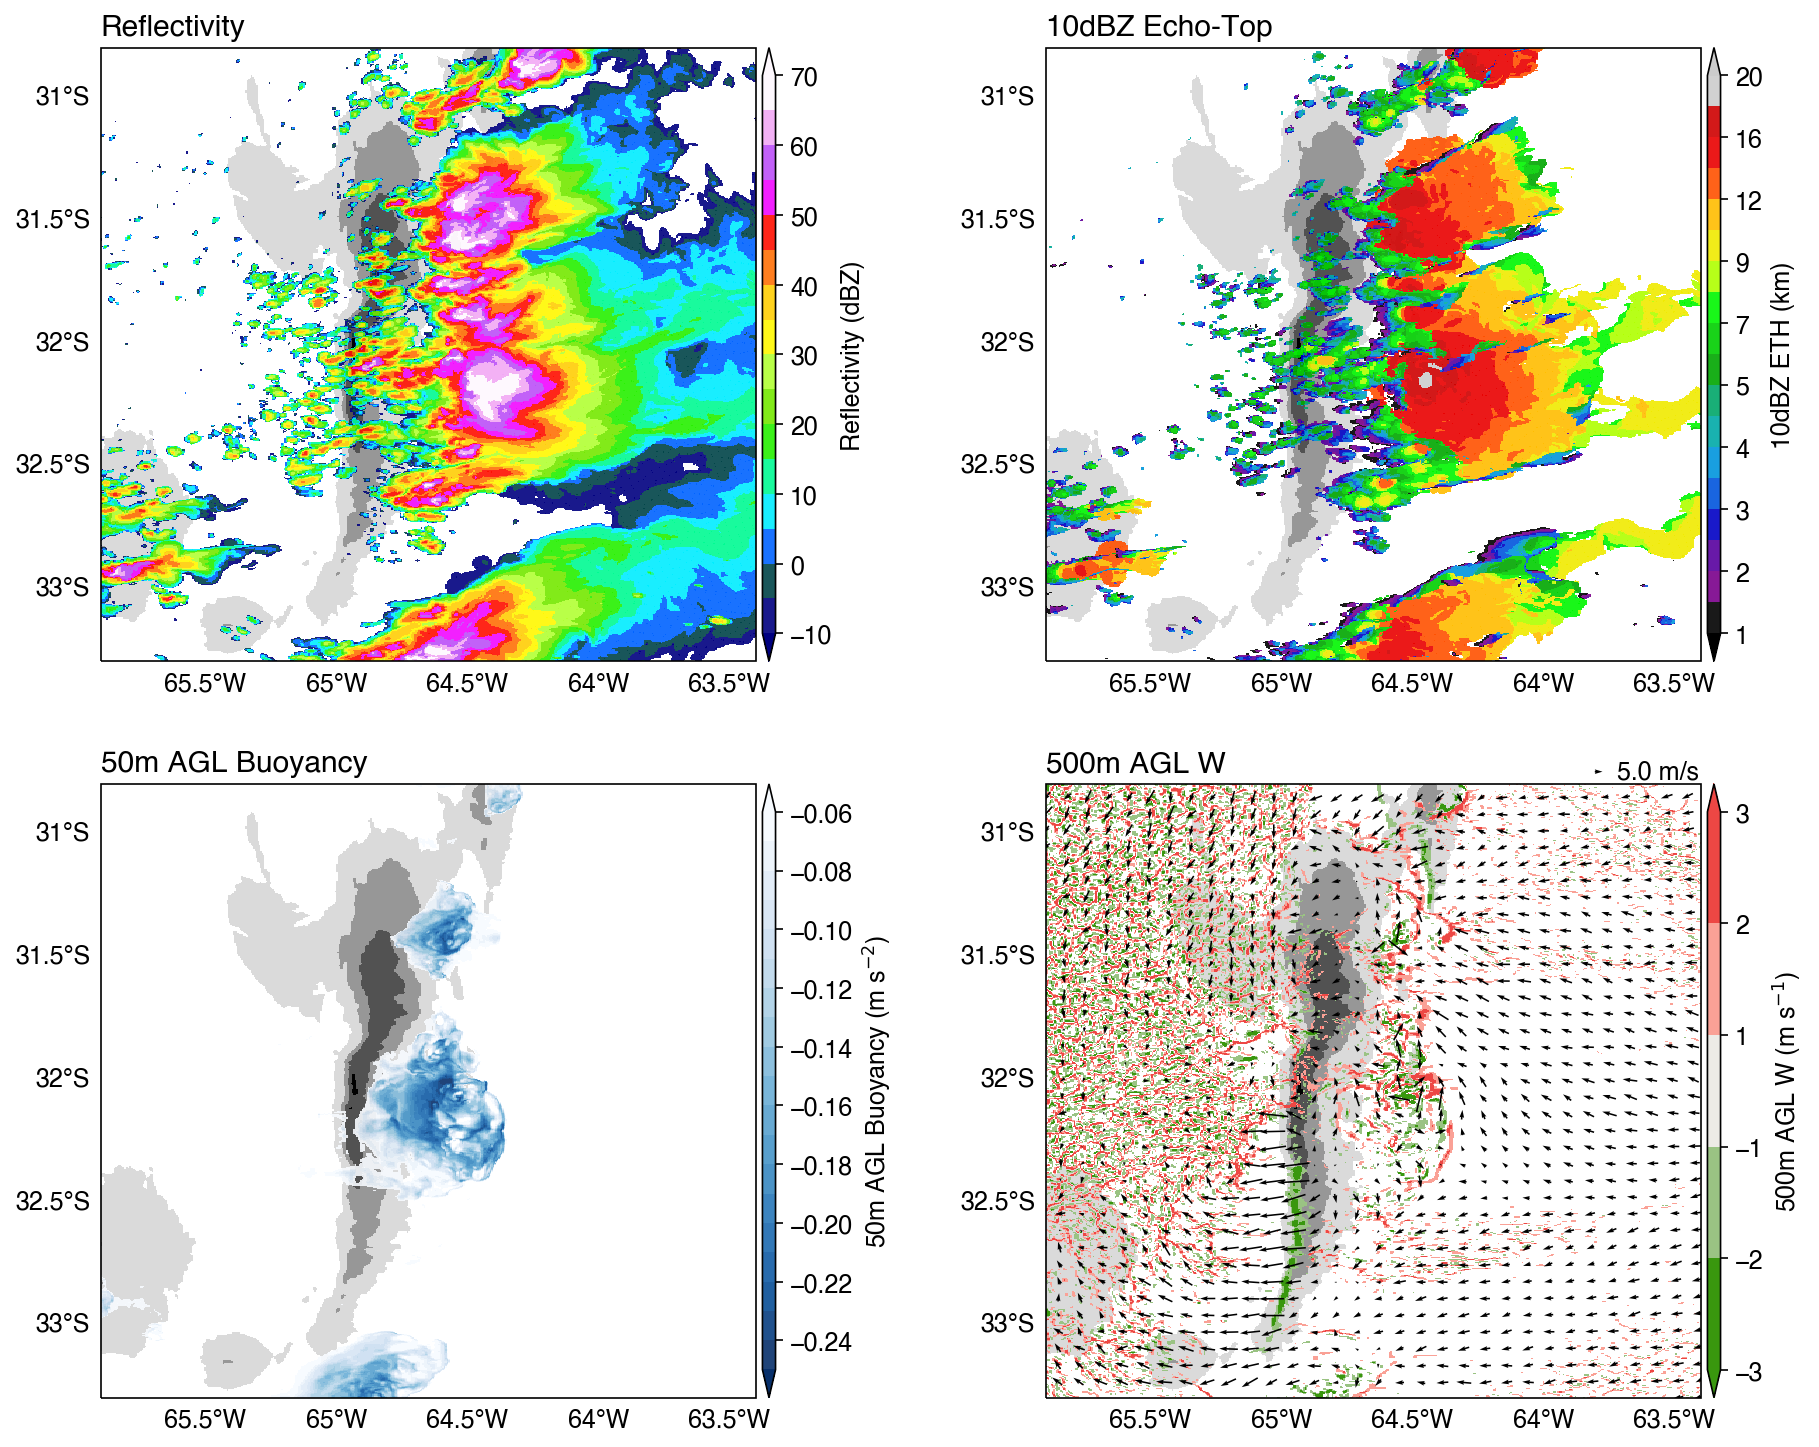

In [43]:
# fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=150)

figsize = (12,12)
fontsize = 12
dpi=150
map_extent = (lonmin, lonmax, latmin, latmax)

proj = ccrs.PlateCarree(central_longitude=0)
data_proj = ccrs.PlateCarree(central_longitude=0)

mpl.rcParams['font.size'] = fontsize
mpl.rcParams['font.family'] = 'Helvetica'
fig = plt.figure(figsize=figsize, dpi=dpi, facecolor='w')

# Two columns
gs = gridspec.GridSpec(1, 2, height_ratios=[1], width_ratios=[0.5,0.5],)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.8, wspace=0.4, hspace=0.1)
# Two rows for each column
gs_l = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0], height_ratios=[1,1], width_ratios=[1,0.02], wspace=0.02, hspace=0.2)
gs_r = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], height_ratios=[1,1], width_ratios=[1,0.02], wspace=0.02, hspace=0.2)
# Setup axes
ax1 = plt.subplot(gs_l[0,0], projection=proj)
ax2 = plt.subplot(gs_r[0,0], projection=proj)
ax3 = plt.subplot(gs_l[1,0], projection=proj)
ax4 = plt.subplot(gs_r[1,0], projection=proj)
cax1 = plt.subplot(gs_l[0,1])
cax2 = plt.subplot(gs_r[0,1])
cax3 = plt.subplot(gs_l[1,1])
cax4 = plt.subplot(gs_r[1,1])

# 
titles = ['Reflectivity','10dBZ Echo-Top',f'{buoy_z}m AGL Buoyancy',f'{W_z}m AGL W']
ax1.set_title(titles[0], loc='left')
ax2.set_title(titles[1], loc='left')
ax3.set_title(titles[2], loc='left')
ax4.set_title(titles[3], loc='left')

# Terrain height
cmap0 = copy.copy(mpl.cm.get_cmap('Greys'))
HGT_lev = np.arange(500, 3001, 500)
norm0 = mpl.colors.BoundaryNorm(boundaries=HGT_lev, ncolors=cmap0.N)

#-----------------------------------------------
# Upper left
#-----------------------------------------------
ax1.set_extent(map_extent, crs=data_proj)
ax1.set_aspect('auto', adjustable=None)
gl = ax1.gridlines(crs=data_proj, draw_labels=True, linestyle='--', linewidth=0)
gl.right_labels = False
gl.top_labels = False
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
# 
cmap1 = copy.copy(mpl.cm.get_cmap('gist_ncar'))
dbz_lev = np.arange(-10, 70.1, 5)
norm = mpl.colors.BoundaryNorm(boundaries=dbz_lev, ncolors=cmap1.N)
var_fill = np.ma.masked_where(dbz_comp < min(dbz_lev), dbz_comp)
pcm0 = ax1.pcolormesh(lon_m, lat_m, HGT, shading='nearest', norm=norm0, cmap=cmap0, transform=data_proj, zorder=0)
pcm1 = ax1.pcolormesh(lon_m, lat_m, var_fill, shading='nearest', norm=norm, cmap=cmap1, transform=data_proj, zorder=1, alpha=0.9)
# Colorbar
cb1 = plt.colorbar(pcm1, cax=cax1, label=f'Reflectivity (dBZ)', ticks=None, extend='both', orientation='vertical')

#-----------------------------------------------
# Upper right
#-----------------------------------------------
ax2.set_extent(map_extent, crs=data_proj)
ax2.set_aspect('auto', adjustable=None)
gl = ax2.gridlines(crs=data_proj, draw_labels=True, linestyle='--', linewidth=0)
gl.right_labels = False
gl.top_labels = False
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
# 
cmap2 = copy.copy(mpl.cm.get_cmap('nipy_spectral'))
eth_lev = [1,1.5,2,2.5,3,3.5,4,4.5,5,6,7,8,9,10,12,14,16,18,20]
norm = mpl.colors.BoundaryNorm(boundaries=eth_lev, ncolors=cmap2.N)
var_fill = np.ma.masked_where(echotop10 < min(eth_lev), echotop10)
pcm0 = ax2.pcolormesh(lon_m, lat_m, HGT, shading='nearest', norm=norm0, cmap=cmap0, transform=data_proj, zorder=0)
pcm2 = ax2.pcolormesh(lon_m, lat_m, var_fill, shading='nearest', norm=norm, cmap=cmap2, transform=data_proj, zorder=1, alpha=0.9)
# Colorbar
cb2 = plt.colorbar(pcm2, cax=cax2, label=f'10dBZ ETH (km)', ticks=None, extend='both', orientation='vertical')


#-----------------------------------------------
# Lower left
#-----------------------------------------------
ax3.set_extent(map_extent, crs=data_proj)
ax3.set_aspect('auto', adjustable=None)
gl = ax3.gridlines(crs=data_proj, draw_labels=True, linestyle='--', linewidth=0)
gl.right_labels = False
gl.top_labels = False
# if (lonv is not None) & (latv is not None):
#     gl.xlocator = mpl.ticker.FixedLocator(lonv)
#     gl.ylocator = mpl.ticker.FixedLocator(latv)
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax3.xaxis.set_major_formatter(lon_formatter)
ax3.yaxis.set_major_formatter(lat_formatter)

cmap3 = copy.copy(mpl.cm.get_cmap('Blues_r'))
buoy_lev = np.arange(-0.25, -0.05, 0.01)
norm = mpl.colors.BoundaryNorm(boundaries=buoy_lev, ncolors=cmap3.N)
pcm0 = ax3.pcolormesh(lon_m, lat_m, HGT, shading='nearest', norm=norm0, cmap=cmap0, transform=data_proj, zorder=0)
pcm3 = ax3.pcolormesh(lon_m, lat_m, buoy_s, shading='nearest', norm=norm, cmap=cmap3, transform=data_proj, zorder=1, alpha=0.9)
# Colorbar
cb3 = plt.colorbar(pcm3, cax=cax3, label=f'{buoy_z}m'+' AGL Buoyancy (m s$^{-2}$)', ticks=None, extend='both', orientation='vertical')


#-----------------------------------------------
# Lower right
#-----------------------------------------------
ax4.set_extent(map_extent, crs=data_proj)
ax4.set_aspect('auto', adjustable=None)
gl = ax4.gridlines(crs=data_proj, draw_labels=True, linestyle='--', linewidth=0)
gl.right_labels = False
gl.top_labels = False

# # cmap = copy.copy(mpl.cm.get_cmap('RdBu_r'))
# ax4 = axes[1]
cmap4 = copy.copy(mpl.cm.get_cmap(cc.cm.CET_D3))
W_lev = [-3,-2,-1,1,2,3]
norm = mpl.colors.BoundaryNorm(boundaries=W_lev, ncolors=cmap4.N)
_W_ll = np.ma.masked_where(np.absolute(W_ll) < 1, W_ll)
pcm0 = ax4.pcolormesh(lon_m, lat_m, HGT, shading='nearest', norm=norm0, cmap=cmap0, transform=data_proj, zorder=0)
pcm4 = ax4.pcolormesh(lon_m, lat_m, _W_ll, shading='nearest', norm=norm, cmap=cmap4, transform=data_proj, zorder=1)
# Wind vectors
nvecs = [15,15]
quiver_width = None  # 0.003
qkscale = 5.0
Q4 = ax4.quiver(lon_m.values[::nvecs[0],::nvecs[1]], lat_m.values[::nvecs[0],::nvecs[1]], \
               U_ll.values[::nvecs[0],::nvecs[1]], V_ll.values[::nvecs[0],::nvecs[1]], \
               # scale=vector_scale, \
               pivot='mid', width=quiver_width, transform=data_proj, zorder=2)
qk4 = ax4.quiverkey(Q4, 0.85, 1.02, qkscale, f'{qkscale} m/s', labelpos='E', coordinates='axes')
# 
cb4 = plt.colorbar(pcm4, cax=cax4, label=f'{W_z}m'+' AGL W (m s$^{-1}$)', ticks=None, extend='both', orientation='vertical')


In [198]:
# def convolve_3d_with_2d_mask(array_3d, mask_2d):
#     # Reshape the 3D array to a 4D array where the first dimension is the same
#     # and the rest corresponds to the 2D planes
#     array_4d = array_3d[:, np.newaxis, :, :]
    
#     # Convolve using the mask across the second and third dimensions
#     convolved_array = convolve(array_4d, mask_2d[np.newaxis, :, :], mode='constant', cval=0.0)
    
#     # Squeeze the extra dimension back to 3D
#     return convolved_array.squeeze(1)

In [203]:
# THETA_V_bar = convolve_3d_with_2d_mask(THETA_V.squeeze().values, mask_convol)

In [167]:
# def convolve_3d_with_2d_mask(array_3d, mask_2d):
#     # Get the shape of the 3D array
#     z_dim, y_dim, x_dim = array_3d.shape
    
#     # Initialize an empty array to store the convolved results
#     convolved_array = np.empty_like(array_3d)
    
#     # Iterate over the z-dimension
#     for z in range(z_dim):
#         # Apply the 2D convolution to the (y, x) slice at each z-level
#         convolved_array[z] = convolve(array_3d[z], mask_2d, mode='nearest')
    
#     return convolved_array

In [168]:
# THETA_V_bar = convolve_3d_with_2d_mask(THETA_V.values.squeeze(), mask_convol)
# # mask_convol.shape

In [169]:
# plt.pcolormesh(THETA_V_bar[1,:,:], vmin=308, vmax=318, cmap='turbo')
# plt.colorbar()

In [170]:
# plt.pcolormesh(THETA_V.values.squeeze()[1,:,:], vmin=305, vmax=320, cmap='turbo')
# plt.colorbar()

In [20]:
# def fft_convolve(array, mask):
#     """Apply convolution using FFT."""
#     # Pad the array and mask to the same size
#     array_padded = np.pad(array, ((0, mask.shape[0]-1), (0, mask.shape[1]-1)), mode='constant')
#     mask_padded = np.pad(mask, ((0, array.shape[0]-1), (0, array.shape[1]-1)), mode='constant')
    
#     # Perform FFT convolution
#     result = ifft2(fft2(array_padded) * fft2(mask_padded)).real
    
#     # Crop the result to match the input size
#     result = result[:array.shape[0], :array.shape[1]]
    
#     return result

In [192]:
# def fft_convolve_3d_along_xy(array_3d, mask_2d):
#     """
#     Apply 2D convolution to each (y, x) slice of a 3D array (z, y, x) using FFT.
#     The array is padded on all four edges to handle boundary conditions, and the
#     result is trimmed to match the original array size.
    
#     Parameters:
#     - array_3d: The input 3D array with shape (z, y, x).
#     - mask_2d: The 2D mask for convolution with shape (y, x).
    
#     Returns:
#     - result: A 3D array with the same shape as array_3d after applying the convolution.
#     """
#     # Get the original dimensions
#     z, y, x = array_3d.shape
    
#     # Determine the padding sizes (half the size of the mask)
#     pad_y = mask_2d.shape[0] // 2
#     pad_x = mask_2d.shape[1] // 2
    
#     # Pad the mask to match the FFT size
#     mask_padded = np.pad(mask_2d, ((0, y + 2 * pad_y - mask_2d.shape[0]), 
#                                    (0, x + 2 * pad_x - mask_2d.shape[1])), 
#                          mode='constant')

#     # Initialize the output array
#     result = np.zeros_like(array_3d)
    
#     # Apply FFT-based convolution to each (y, x) slice along the z-axis
#     for i in range(z):
#         # Pad the (y, x) slice of the 3D array
#         slice_padded = np.pad(array_3d[i], ((pad_y, pad_y), (pad_x, pad_x)), mode='constant')
        
#         # Perform the FFT convolution
#         convolved = ifft2(fft2(slice_padded) * fft2(mask_padded)).real
        
#         # Trim the padded regions to match the original size
#         result[i] = convolved[pad_y:pad_y + y, pad_x:pad_x + x]
    
#     return result

In [22]:
# def fft_convolve_2d(array_2d, mask_2d):
#     """
#     Apply 2D convolution to a 2D array using FFT. The array is padded on all four edges 
#     to handle boundary conditions, and the result is trimmed to match the original array size.
    
#     Parameters:
#     - array_2d: The input 2D array with shape (y, x).
#     - mask_2d: The 2D mask for convolution with shape (y, x).
    
#     Returns:
#     - result: A 2D array with the same shape as array_2d after applying the convolution.
#     """
#     # Get the original dimensions
#     y, x = array_2d.shape
    
#     # Determine the padding sizes (half the size of the mask)
#     pad_y = mask_2d.shape[0] // 2
#     pad_x = mask_2d.shape[1] // 2
#     print(pad_y, pad_x)
    
#     # Pad the mask to match the FFT size
#     mask_padded = np.pad(mask_2d, ((0, y + 2 * pad_y - mask_2d.shape[0]), 
#                                    (0, x + 2 * pad_x - mask_2d.shape[1])), 
#                          mode='constant')

#     # Pad the (y, x) array
#     array_padded = np.pad(array_2d, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
#     print(array_padded.shape, mask_padded.shape)
    
#     # Perform the FFT convolution
#     convolved = ifft2(fft2(array_padded) * fft2(mask_padded)).real
    
#     # Trim the padded regions to match the original size
#     result = convolved[pad_y:pad_y + y, pad_x:pad_x + x]
#     # result = convolved
    
#     return array_padded, mask_padded, result

In [161]:
# def fft_convolve_2d(array_2d, mask_2d, pad_mode='edge'):
#     """
#     Apply 2D convolution to a 2D array using FFT. The array is padded with extended padding 
#     to better mimic the 'nearest' mode in scipy.ndimage.convolve, and the result is trimmed 
#     to match the original array size.
    
#     Parameters:
#     - array_2d: The input 2D array with shape (y, x).
#     - mask_2d: The 2D mask for convolution with shape (y, x).
#     - pad_mode: The mode for padding the input 2D array, default='edge'.
    
#     Returns:
#     - result: A 2D array with the same shape as array_2d after applying the convolution.
#     """
#     # Get the original dimensions
#     y, x = array_2d.shape
    
#     # Determine the padding sizes (half the size of the mask)
#     pad_y = int(mask_2d.shape[0] // 1)
#     pad_x = int(mask_2d.shape[1] // 1)
    
#     # Extended padding: create a larger padding that mimics 'nearest' mode more closely
#     array_padded = np.pad(array_2d, ((pad_y, pad_y), (pad_x, pad_x)), mode=pad_mode)
    
#     # Pad the mask to match the size of the padded array slice
#     mask_padded = np.zeros_like(array_padded)
#     # Place the original mask in the lower left corner of the padded array
#     mask_padded[:mask_2d.shape[0], :mask_2d.shape[1]] = mask_2d
    
#     # Perform the FFT convolution
#     convolved = ifft2(fft2(array_padded) * fft2(mask_padded)).real
    
#     # Trim the padded regions to match the original size
#     result = convolved[pad_y:pad_y + y, pad_x:pad_x + x]
    
#     return array_padded, mask_padded, result

In [151]:
# def fft_convolve_2d(array_2d, mask_2d, pad_mode='edge'):
#     """
#     Apply 2D convolution to a 2D array using FFT, with padding using repeated edge values 
#     to approximate the 'nearest' mode in scipy.ndimage.convolve.
    
#     Parameters:
#     - array_2d: The input 2D array with shape (y, x).
#     - mask_2d: The 2D mask for convolution with shape (y, x).
    
#     Returns:
#     - result: A 2D array with the same shape as array_2d after applying the convolution.
#     """
#     # Get the original dimensions
#     y, x = array_2d.shape
    
#     # Determine the padding sizes (half the size of the mask)
#     pad_y = mask_2d.shape[0] // 2
#     pad_x = mask_2d.shape[1] // 2
    
#     # Pad the array with edge values
#     array_padded = np.pad(array_2d, ((pad_y, pad_y), (pad_x, pad_x)), mode=pad_mode)
    
#     # Create the weighting mask that reduces the influence of the padded area
#     # weight_mask = np.ones_like(array_padded)
#     # weight_mask[pad_y:-pad_y, pad_x:-pad_x] = 0
#     weight_mask = np.zeros_like(array_padded)
#     weight_mask[pad_y:-pad_y, pad_x:-pad_x] = 1
    
#     # Pad the mask to match the size of the padded array
#     mask_padded = np.zeros_like(array_padded)
#     mask_padded[:mask_2d.shape[0], :mask_2d.shape[1]] = mask_2d
#     # center_y = (mask_padded.shape[0] - mask_2d.shape[0]) // 2
#     # center_x = (mask_padded.shape[1] - mask_2d.shape[1]) // 2
#     # mask_padded[center_y:center_y + mask_2d.shape[0], center_x:center_x + mask_2d.shape[1]] = mask_2d
    
#     # Perform the FFT convolution
#     convolved = ifft2(fft2(array_padded) * fft2(mask_padded)).real
    
#     # Normalize by the weight mask convolution
#     weight_convolved = ifft2(fft2(weight_mask) * fft2(mask_padded)).real
    
#     # # Avoid division by zero in normalization
#     with np.errstate(divide='ignore', invalid='ignore'):
#         result = convolved / weight_convolved
#         result[weight_convolved == 0] = 0
#     # result = convolved
    
#     # Trim the padded regions to match the original size
#     result = result[pad_y:pad_y + y, pad_x:pad_x + x]

#     return array_padded, mask_padded, weight_mask, weight_convolved, result

In [181]:
# def fft_convolve_2d(array_2d, mask_2d):
#     """
#     Perform FFT-based convolution on a 2D array with a 2D mask.
    
#     Parameters:
#     - array_2d: The input 2D array with shape (y, x).
#     - mask_2d: The 2D mask for convolution with shape (m_y, m_x).
    
#     Returns:
#     - result: A 2D array with the same shape as array_2d after applying the convolution.
#     """
#     # Get the original dimensions of the input array and the mask
#     y, x = array_2d.shape
#     m_y, m_x = mask_2d.shape
    
#     # Calculate the padding needed for the array and mask
#     pad_y = m_y - 1
#     pad_x = m_x - 1
    
#     # Pad the input array to avoid wraparound effects
#     array_padded = np.pad(array_2d, ((0, pad_y), (0, pad_x)), mode='edge')
    
#     # Create a zero-padded mask with the same size as the padded array
#     mask_padded = np.zeros_like(array_padded)
    
#     # Place the original mask at the top-left corner of the padded mask
#     mask_padded[:m_y, :m_x] = mask_2d
    
#     # Perform FFT-based convolution
#     convolved = ifft2(fft2(array_padded) * fft2(mask_padded)).real
    
#     # Crop the result to match the original input array size
#     result = convolved[:y, :x]

#     return array_padded, mask_padded, result

In [182]:
#  # = fft_convolve_2d(THETA_V_ll.values, mask_convol)
# THETA_V_ll.shape, mask_convol.shape

In [183]:
# array_padded, mask_padded, test = fft_convolve_2d(THETA_V_ll.values, mask_convol)

# # array_padded, mask_padded, weight_mask, weight_convolved, test = fft_convolve_2d(THETA_V_ll.values, mask_convol, pad_mode='edge')

In [184]:
# plt.pcolormesh(array_padded, vmin=305, vmax=320, cmap='turbo')
# plt.colorbar()

In [185]:
# plt.pcolormesh(mask_padded, cmap='turbo')
# plt.colorbar()

In [186]:
# plt.pcolormesh(weight_mask, cmap='turbo')
# plt.colorbar()

In [187]:
# weight_convolved[800,:]

In [188]:
# plt.pcolormesh(weight_convolved, cmap='turbo')
# plt.colorbar()

In [189]:
# # test.shape
# plt.pcolormesh(test, vmin=305, vmax=320, cmap='turbo')
# plt.colorbar()

In [190]:
# # THETA_V_ll_bar.shape, test.shape
# diff = test - THETA_V_ll_bar
# plt.pcolormesh(diff, cmap='RdBu_r')
# plt.colorbar()

In [191]:
# diff = test - THETA_V_ll_bar
# plt.pcolormesh(diff, cmap='RdBu_r')
# plt.colorbar()

In [55]:
# array_padded = np.pad(THETA_V_ll.values, ((0, mask_convol.shape[0]-1), (0, mask_convol.shape[1]-1)), mode='constant')
# mask_padded = np.pad(mask_convol, ((0, THETA_V_ll.shape[0]-1), (0, THETA_V_ll.shape[1]-1)), mode='constant')

In [56]:
# array_padded.shape, mask_padded.shape

In [57]:
# plt.pcolormesh(array_padded, vmin=305, vmax=320, cmap='turbo')
# plt.colorbar()

In [58]:
# result = fft_convolve(THETA_V_ll.values, mask_convol)

In [59]:
# # THETA_V_ll.shape, mask_convol.shape
# plt.pcolormesh(result, vmin=308, vmax=318, cmap='turbo')
# plt.colorbar()